In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

import numpy as np
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

10:58:14 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=320338;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=289483;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=863559;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=477267;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=968053;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=667520;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

10:58:14 INFO      Starting 3ML!                                                                     ]8;id=319002;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=436783;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=566362;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=294445;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=874109;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=330729;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=447770;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=582272;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=231306;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=487061;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=398387;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=31571;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=76153;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=531567;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [3]:
multiplier_1068 = 1

# Exposure changes count statistics, not the intrinsic spectra plotted below.
exposure_1068 = multiplier_1068 * 3

norm_nt = 0.90

# Source Model Plots

## Cutoff Power Law (Thermal)

### NGC 1068 EC128

In [4]:
K_inj = 3.1e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 128. * u.keV
index_inj = -2.10

spectrum_inj_ec128 = Cutoff_powerlaw()

spectrum_inj_ec128.K.value = K_inj.value
spectrum_inj_ec128.piv.value = piv_inj.value
spectrum_inj_ec128.xc.value = xc_inj.value
spectrum_inj_ec128.index.value = index_inj

spectrum_inj_ec128.K.unit = K_inj.unit
spectrum_inj_ec128.piv.unit = piv_inj.unit
spectrum_inj_ec128.xc.unit = xc_inj.unit

print(spectrum_inj_ec128.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec128).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec128.K.value
    * (200.0 / spectrum_inj_ec128.piv.value) ** spectrum_inj_ec128.index.value
)

print(K_inj_at_fit_pivot)

9.56342761276575e-07
energy_flux:  2.5776693877543373e-11 erg / (s cm2)
energy_flux_err:  5.515109721531423e-20 erg / (s cm2)
4.562456144556676e-06


### Case 2

#### NGC 1068 (200 keV)

In [5]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = norm_nt*spectrum_inj_ec128.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -2.8

spectrum_inj_ec128_PL = Powerlaw()

spectrum_inj_ec128_PL.K.value = K_inj.value
spectrum_inj_ec128_PL.piv.value = piv_inj.value
spectrum_inj_ec128_PL.index.value = index_inj

spectrum_inj_ec128_PL.K.unit = K_inj.unit
spectrum_inj_ec128_PL.piv.unit = piv_inj.unit

spectrum_inj_ec128_total = spectrum_inj_ec128 + spectrum_inj_ec128_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec128.evaluate_at(200))
print(spectrum_inj_ec128_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec128_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec128,
    spectrum_inj_ec128_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec128_PL.evaluate_at(200)/spectrum_inj_ec128.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec128.evaluate_at(E), 100.0, 10000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec128_PL.evaluate_at(E), 100.0, 10000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec128 + spectrum_inj_ec128_PL).evaluate_at(E),
    100.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec128.K.value
    * (200.0 / spectrum_inj_ec128.piv.value) ** spectrum_inj_ec128.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  8.607084851489174e-07 1 / (keV s cm2)
9.56342761276575e-07
8.607084851489176e-07
Linking K ratio 0.18865024843598815
Flux ratio at 200 keV 0.9000000000000002
Non-thermal energy flux:  1.1703402615906527e-10 erg / (s cm2)
Total energy flux:  2.1280079987804155e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  0.8182814593494042
Non-thermal energy flux percentage:  0.549969860198546
energy_flux:  2.1280079987804155e-10 erg / (s cm2)
energy_flux_err:  2.0039350640827057e-19 erg / (s cm2)
4.562456144556676e-06


In [6]:
# # Replace the hard step with a continuous broken power law.
# # Below 200 keV the positive index suppresses the tail smoothly; above
# # 200 keV the model retains the original -3.8 non-thermal slope.

# spectrum_inj_ec128_PL_unbroken = spectrum_inj_ec128_PL

# break_energy = 400.0 * u.keV
# index_below_break = -3
# index_above_break = spectrum_inj_ec128_PL_unbroken.index.value
# K_at_break = (
#     spectrum_inj_ec128_PL_unbroken.evaluate_at(break_energy.value)
#     / u.cm / u.cm / u.s / u.keV
# )

# spectrum_inj_ec128_BPL = Broken_powerlaw()
# spectrum_inj_ec128_BPL.K.value = K_at_break.value
# spectrum_inj_ec128_BPL.xb.value = break_energy.value
# spectrum_inj_ec128_BPL.piv.value = break_energy.value
# spectrum_inj_ec128_BPL.alpha.value = index_below_break
# spectrum_inj_ec128_BPL.beta.value = index_above_break
# spectrum_inj_ec128_BPL.K.unit = K_at_break.unit
# spectrum_inj_ec128_BPL.xb.unit = break_energy.unit
# spectrum_inj_ec128_BPL.piv.unit = break_energy.unit

# # Keep the existing variable name so the plotting cells below use the BPL.
# spectrum_inj_ec128_PL = spectrum_inj_ec128_BPL
# spectrum_inj_ec128_total = spectrum_inj_ec128 + spectrum_inj_ec128_PL

# print("K_inj: ", K_inj)
# print(spectrum_inj_ec128.evaluate_at(200))
# print(spectrum_inj_ec128_PL.evaluate_at(200))
# print("="*40)
# linking_ratio_ec200 = spectrum_inj_ec128_PL.K.value / cutoff_powerlaw_k_at_pivot(
#     spectrum_inj_ec128,
#     spectrum_inj_ec128_PL.piv.value,
# )
# print("Linking K ratio", linking_ratio_ec200)
# print("Flux ratio at 200 keV", spectrum_inj_ec128_PL.evaluate_at(200)/spectrum_inj_ec128.evaluate_at(200))
# print("="*40)
# energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec128.evaluate_at(E), 100.0, 10000.0)
# energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec128_PL.evaluate_at(E), 100.0, 10000.0)
# energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# print("Non-thermal energy flux: ", energy_flux_nth)
# print("Total energy flux: ", energy_flux_th + energy_flux_nth)
# print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
# print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

# energy_flux_kev, energy_flux_kev_err = quad(
#     lambda E: E * (spectrum_inj_ec128 + spectrum_inj_ec128_PL).evaluate_at(E),
#     200.0,
#     10000.0,
# )

# energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

# print("energy_flux: ", energy_flux)
# print("energy_flux_err: ", energy_flux_err)

# K_inj_at_fit_pivot = (
#     spectrum_inj_ec128.K.value
#     * (200.0 / spectrum_inj_ec128.piv.value) ** spectrum_inj_ec128.index.value
# )

# print(K_inj_at_fit_pivot)

### Case 3

In [7]:
K_inj = 3.5e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 128. * u.keV
index_inj = -1.9

spectrum_inj_ec128_testa = Cutoff_powerlaw()

spectrum_inj_ec128_testa.K.value = K_inj.value
spectrum_inj_ec128_testa.piv.value = piv_inj.value
spectrum_inj_ec128_testa.xc.value = xc_inj.value
spectrum_inj_ec128_testa.index.value = index_inj

spectrum_inj_ec128_testa.K.unit = K_inj.unit
spectrum_inj_ec128_testa.piv.unit = piv_inj.unit
spectrum_inj_ec128_testa.xc.unit = xc_inj.unit

print(spectrum_inj_ec128_testa.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec128_testa).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec128_testa.K.value
    * (200.0 / spectrum_inj_ec128_testa.piv.value) ** spectrum_inj_ec128_testa.index.value
)

print(K_inj_at_fit_pivot)

3.1154868651488162e-06
energy_flux:  8.991692060385934e-11 erg / (s cm2)
energy_flux_err:  7.774897285240269e-20 erg / (s cm2)
1.4863156565549669e-05


#### NGC 1068 (200 keV) Non-thermal cutoff

In [8]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = 0.10*spectrum_inj_ec128_testa.evaluate_at(1) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
index_inj = -1.85
cutoff_inj = 3750. * u.keV

spectrum_inj_ec128_PL_testa = Cutoff_powerlaw()

spectrum_inj_ec128_PL_testa.K.value = K_inj.value
spectrum_inj_ec128_PL_testa.piv.value = piv_inj.value
spectrum_inj_ec128_PL_testa.index.value = index_inj
spectrum_inj_ec128_PL_testa.xc.value = cutoff_inj.value

spectrum_inj_ec128_PL_testa.K.unit = K_inj.unit
spectrum_inj_ec128_PL_testa.piv.unit = piv_inj.unit
spectrum_inj_ec128_PL_testa.xc.unit = cutoff_inj.unit

spectrum_inj_ec128_total = spectrum_inj_ec128_testa + spectrum_inj_ec128_PL_testa

print(spectrum_inj_ec128_testa.evaluate_at(200))
print(spectrum_inj_ec128_PL_testa.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec128_PL_testa.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec128_testa,
    spectrum_inj_ec128_PL_testa.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec128_PL_testa.evaluate_at(200)/spectrum_inj_ec128_testa.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec128_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec128_PL_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec128_testa + spectrum_inj_ec128_PL_testa).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec128_testa.K.value
    * (200.0 / spectrum_inj_ec128_testa.piv.value) ** spectrum_inj_ec128_testa.index.value
)

print(K_inj_at_fit_pivot)

3.1154868651488162e-06
1.8222470438467002e-06
Linking K ratio 0.09922179382602433
Flux ratio at 200 keV 0.5848996072591877
Non-thermal energy flux:  3.4654612200635097e-10 erg / (s cm2)
Total energy flux:  4.364630426102103e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  0.25946595530568795
Non-thermal energy flux percentage:  0.7939873212033648
energy_flux:  4.3646304261021026e-10 erg / (s cm2)
energy_flux_err:  7.295211655119694e-20 erg / (s cm2)
1.4863156565549669e-05


In [9]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_inj_ec128 = np.zeros_like(energy)
flux_inj_ec128_PL = np.zeros_like(energy)
flux_inj_ec128_testa = np.zeros_like(energy)
flux_inj_ec128_PL_testa = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec128[i] = spectrum_inj_ec128.evaluate_at(e)
    flux_inj_ec128_PL[i] = spectrum_inj_ec128_PL.evaluate_at(e)
    flux_inj_ec128_testa[i] = spectrum_inj_ec128_testa.evaluate_at(e)
    flux_inj_ec128_PL_testa[i] = spectrum_inj_ec128_PL_testa.evaluate_at(e)

Plot the fitted and injected spectra

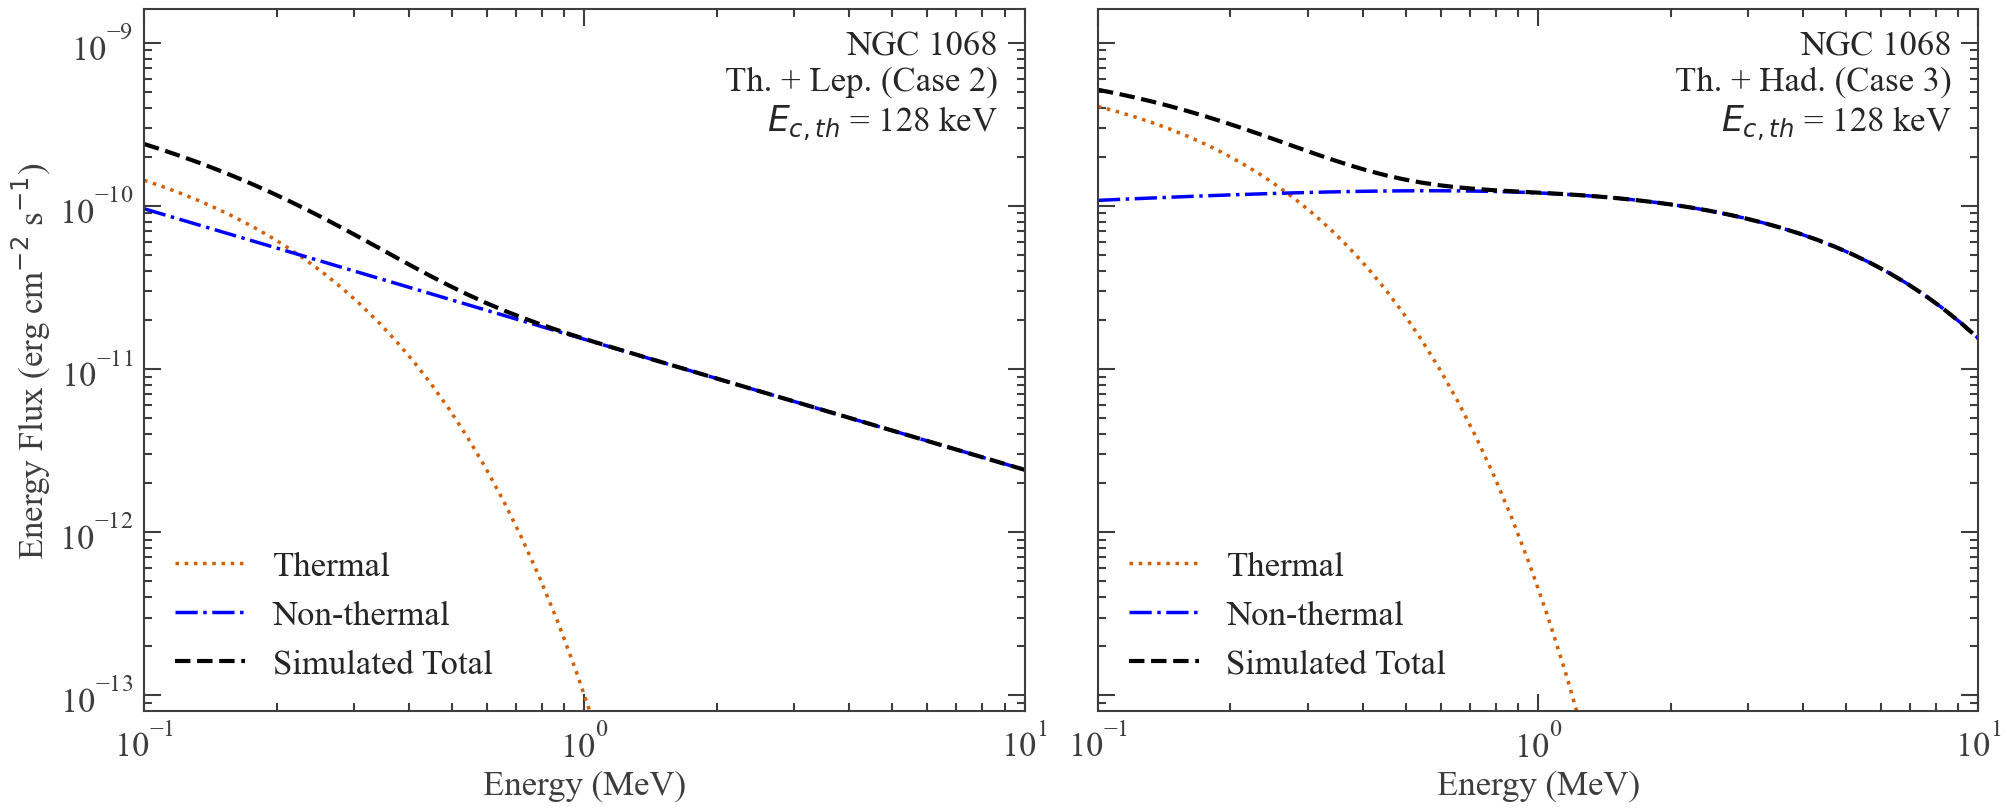

In [10]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.ravel()

for ax in axes:
    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
    ax.set_xlim((100) * KEV_TO_MEV, (10000) * KEV_TO_MEV)
    # ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
    # ax.xaxis.set_major_formatter(
    #     mticker.FixedFormatter(["0.1", "5", "10"])
    # )
    ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)

axes[0].set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

# Panel 1: Case 2 with a 0.2 MeV thermal cutoff.
axes[0].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj_ec128, color='#D55E00', ls=':', lw=2.5, label='Thermal')
axes[0].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj_ec128_PL, color='blue', ls='-.', lw=2.5, label='Non-thermal')
axes[0].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec128 + flux_inj_ec128_PL), color='black', ls='--', lw=3, label='Simulated Total')
axes[0].text(
    0.97, 0.97,
    'NGC 1068\nTh. + Lep. (Case 2)\n$E_{c,th}$ = 128 keV',
    transform=axes[0].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[0].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Panel 2: Case 3 thermal plus cutoff-power-law non-thermal component.
axes[1].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj_ec128_testa, color='#D55E00', ls=':', lw=2.5, label='Thermal')
axes[1].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * flux_inj_ec128_PL_testa, color='blue', ls='-.', lw=2.5, label='Non-thermal')
axes[1].plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec128_testa + flux_inj_ec128_PL_testa), color='black', ls='--', lw=3, label='Simulated Total')
axes[1].text(
    0.97, 0.97,
    f"NGC 1068\nTh. + Had. (Case 3)\n$E_{{c,th}}$ = {spectrum_inj_ec128_testa.xc.value:.0f} keV",
    transform=axes[1].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[1].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/NGC1068_Case2_Case3_Two_Panel.pdf"
# plt.savefig(save_path, bbox_inches='tight')
